In [1]:
import os

import numpy as np
import pandas as pd

from scripts.data_loader import load_dataframe
from scripts.data_processing import cluster_data_and_train_random_forest
from scripts.utils import extract_unique_npcis, RF_PARAM

# source files
BASE_DIR = "data/"
FULL_DATA_SET = "Campaign_data_NBIoT_1_2_3_4_5_6_interpolated_smoothed.mat"
filename = os.path.join(BASE_DIR, FULL_DATA_SET)

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename)

Loaded dataframe from .h5 file: data/Campaign_data_NBIoT_1_2_3_4_5_6_interpolated_smoothed.mat_dataframe.h5


In [2]:
from scripts.weighted_coverage import create_point_matrix, compute_weights, wknn_one


def process_single_test_point(single_tp, df_rp, unique_npcis, rf_param, k_max):
    # Ensure single_tp is a DataFrame with one row for consistency
    df_tp = pd.DataFrame([single_tp])

    # Create the point matrix for the reference points
    m_rfp, idx_rfp = create_point_matrix(df_rp, unique_npcis, rf_param)

    # Create the point matrix for the single test point
    m_tp, idx_tp = create_point_matrix(df_tp, unique_npcis, rf_param)

    # Compute the weights between the single test point and reference points
    W, idx_sort = compute_weights(m_rfp, idx_rfp, m_tp, idx_tp)

    #print(f"* MATRIX RP {m_rfp.shape} TP {m_tp.shape} W {W.shape}")

    # Do wKNN to estimate the position and error for the single test point
    TP_est_location, k_avg_error, selected_RPS = wknn_one(
        df_tp, df_rp, idx_sort, W, k_max
    )

    return TP_est_location, k_avg_error, selected_RPS, W

# Example usage:
# single_test_point = df_tp.iloc[0]  # Assuming df_tp is your test points DataFrame
# result = process_single_test_point(single_test_point, df_rp, unique_npcis, rf_param, k_max)


In [3]:
rand = 42
#df = df.sample(20, random_state=rand)

In [4]:
from itertools import chain
from scripts.utils import dataset_tp_rp_split
from scripts.weighted_coverage import process_test_points

unique_npcis = extract_unique_npcis(df, [1, 10, 88])
rf_param = RF_PARAM.NSINR
n_clusters = 2

print(df.index)
rf_model = cluster_data_and_train_random_forest(df, n_clusters, unique_npcis, rf_param, rand)

df_tp, df_rp = dataset_tp_rp_split(df, 0.3, rand)

print(f'TPS {df_tp.shape[0]} RPS {df_rp.shape[0]}')
print(df_tp['cluster'].value_counts())


def investiage_tp(idx: int):
    print(f"=====INVESTIGATING {idx} ======")
    tp = df_tp.loc[idx]

    print("\tTesting without clustering")
    print(f"\tReference points {df_rp.index.values}")
    TP_est_location, k_avg_error, selected_RPS, W = process_single_test_point(tp, df_rp, unique_npcis, rf_param, 2)

    print("\tTesting with clustering for TP")
    c = tp['cluster']
    cluster_rps = df_rp[df_rp['cluster'] == c]
    print(f"\tReference points for {c} -> {cluster_rps.index.values}")
    cTP_est_location, ck_avg_error, cW = process_single_test_point(tp, cluster_rps, unique_npcis,
                                                                   rf_param,
                                                                   2)
    return k_avg_error == ck_avg_error


# for i in range(5):
#     print(f'res {i}: {investiage_tp(i)}')


TP_est_location, errors_base, W = process_test_points(df_tp, df_rp, unique_npcis, rf_param, 2)

cluster_errors = []
for cluster, group in df_tp.groupby('cluster'):
    tps = group
    rps = df_rp[df_rp['cluster'] == cluster]

    _, errors_base, _ = process_test_points(df_tp, df_rp, unique_npcis, rf_param, 2)
    cluster_errors.append(errors_base)

all_errors_flat = list(chain.from_iterable(cluster_errors))

all_errors_flat = np.array(all_errors_flat).mean()

print(f'Error base mean {errors_base.mean()}')
print(f'Error cluster mean {all_errors_flat.mean()}')


Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2660, 2661, 2662, 2663, 2664, 2665, 2666, 2667, 2668, 2669],
      dtype='int64', length=2670)
TPS 813 RPS 1857
cluster
0    672
1    141
Name: count, dtype: int64


ValueError: not enough values to unpack (expected 3, got 2)

In [16]:
from scripts.utils import dataset_tp_rp_split
from scripts.weighted_coverage import run_weighted_coverage

k_val_wknn = 2
unique_npcis = extract_unique_npcis(df, [1, 10, 88])
rf_param = RF_PARAM.NSINR

#df = df.sample(100)  # limit number of points for debugging

n_runs = 40

cluster_df2 = pd.DataFrame()

cluster = 10
results = []
print(f"\r*** {cluster} clusters")
for c in range(cluster + 1, 21):
    results = []
    print(f"\r✅ Running with {c} cluster(s)")
    for i in range(n_runs):
        random = random_seeds[i]
        print(f'\r🔄 {i + 1} / {n_runs}', end="")

        # Copy df to get clean slate trouble and shuffle it
        tmp = df.copy().sample(frac=1, random_state=random).reset_index(drop=True)

        df_tp, df_rp = dataset_tp_rp_split(tmp, 0.3, random)

        if c == 0:
            _, base_error, _, _ = run_weighted_coverage(
                df_rp, df_tp, rf_param, k_val_wknn, unique_npcis, random, c, False, None
            )
            results.append(base_error.mean())
            continue

        # Clustering
        rf_model = cluster_data_and_train_random_forest(df_rp, c, unique_npcis, rf_param, random)

        _, wknn_err, _, _ = run_weighted_coverage(
            df_rp, df_tp, rf_param, k_val_wknn, unique_npcis, random, c, True, rf_model
        )

        results.append(wknn_err.mean())

    results_df = pd.DataFrame(results, columns=[f'{c}'])
    cluster_df2 = pd.concat([cluster_df2, results_df], axis=1)


*** 10 clusters
✅ Running with 11 cluster(s)
✅ Running with 12 cluster(s)
✅ Running with 13 cluster(s)
✅ Running with 14 cluster(s)
✅ Running with 15 cluster(s)
✅ Running with 16 cluster(s)
✅ Running with 17 cluster(s)
✅ Running with 18 cluster(s)
✅ Running with 19 cluster(s)
✅ Running with 20 cluster(s)
🔄 40 / 40

In [12]:

print(cluster_df.columns)
print("Cluster\tError mean")
skip = False
for col in cluster_df.columns:
    print(f'{col}\t{cluster_df[col].mean()}')

cluster_df

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'], dtype='object')
Cluster	Error mean
0	14.37047036867225
1	14.37047036867225
2	14.396333295580558
3	14.355929518253026
4	14.458536849597783
5	14.575107445275961
6	14.568399782448788
7	14.626477191871123
8	14.639519222439613
9	14.602025168910824
10	14.615755069819823


,0,1,2,3,4,5,6,7,8,9,10
0,16.128535,16.128535,16.181947,16.204070,16.015528,16.128606,16.213698,16.432030,16.438743,16.167225,16.062597
1,12.943326,12.943326,12.943326,13.106758,12.834907,12.913479,13.128615,13.249263,13.050028,13.001506,13.293527
2,14.142183,14.142183,14.122870,14.164217,14.152836,14.522187,14.222303,14.401707,14.099829,13.970663,14.239036
3,15.167541,15.167541,15.167541,15.060762,15.246014,15.439294,15.497980,15.140564,15.277442,15.305293,15.396863
4,15.365097,15.365097,15.365097,15.473655,15.622598,15.486412,15.253476,15.608840,16.032573,15.888614,15.428760
5,15.425615,15.425615,15.483058,15.446830,15.452486,15.563608,15.598389,15.585772,15.754450,15.612155,15.676360
6,14.826082,14.826082,14.877107,14.912748,14.792660,15.132592,15.137656,14.834251,15.064520,15.164008,15.527610
7,13.215978,13.215978,13.215978,13.177128,13.492383,13.363469,13.320351,13.564161,13.627569,13.568590,13.234189
8,13.285594,13.285594,13.302847,13.228839,13.278660,13.339106,13.393343,13.668502,13.702512,13.540888,13.701220
9,15.577662,15.577662,15.440426,15.519416,15.698136,15.859815,15.850243,16.030032,15.829345,15.638603,15.849746


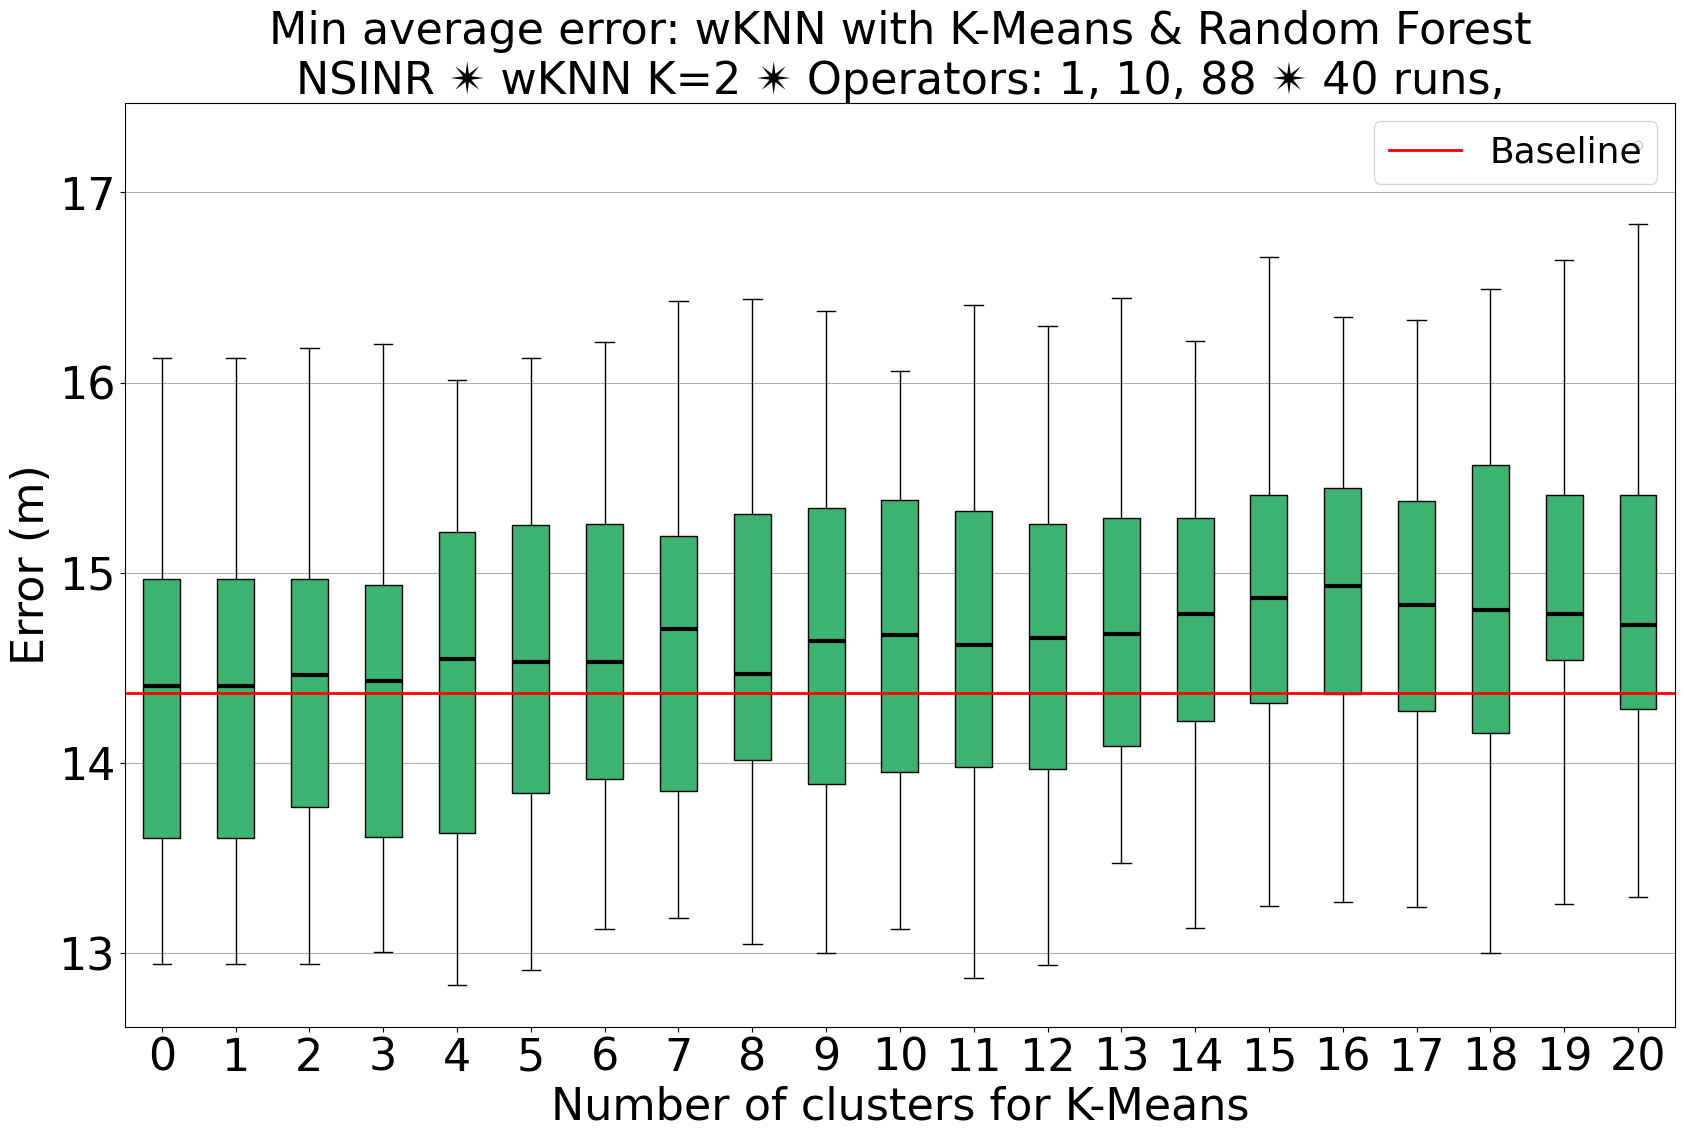

In [17]:
from scripts.plotting import make_boxplot

base_error = cluster_df['0'].mean()
title_string = f"wKNN with K-Means & Random Forest\n{rf_param.value} ✴︎ wKNN K={k_val_wknn} ✴︎ Operators: {', '.join(['1', '10', '88'])} ✴︎ {n_runs} runs,"

total_df = pd.concat([cluster_df, cluster_df2], axis=1)

make_boxplot(
    df=total_df,
    title=f'Min average error: {title_string}',
    x_label='Number of clusters for K-Means',
    y_label='Error (m)',
    color='mediumseagreen',
    baseline=base_error,
)
